In [ ]:
import pandas as pd

In [ ]:
employee_df = pd.read_csv('/content/employee_income.csv')
display(employee_df.head())

,age,experience,income
0,50,5,45118
1,36,9,41691
2,29,3,35994
3,42,5,41614
4,40,12,51474


### 1. Initial Data Inspection
Let's start by getting a general overview of the dataset, including its shape, data types, and a summary of non-null values. We'll also check for basic descriptive statistics.

In [ ]:
print('DataFrame Shape:', employee_df.shape)
print('\nDataFrame Info:')
employee_df.info()

DataFrame Shape: (50, 3)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         50 non-null     int64
 1   experience  50 non-null     int64
 2   income      50 non-null     int64
dtypes: int64(3)
memory usage: 1.3 KB


In [ ]:
print('\nDescriptive Statistics:')
display(employee_df.describe())


Descriptive Statistics:


,age,experience,income
count,50.000000,50.000000,50.000000
mean,38.860000,8.580000,44864.060000
std,10.719066,4.116121,6916.729587
min,23.000000,0.000000,28559.000000
25%,29.250000,6.250000,41039.250000
50%,39.500000,9.000000,46205.000000
75%,46.000000,12.000000,50064.000000
max,59.000000,14.000000,57092.000000


### 2. Check for Missing Values
It's crucial to identify if there are any missing values in the dataset, as this can affect our analysis.

In [ ]:
print('\nMissing Values:')
display(employee_df.isnull().sum())


Missing Values:


,0
age,0
experience,0
income,0


### 3. Univariate Analysis: Distribution of Numerical Features
Let's visualize the distribution of each numerical column (`age`, `experience`, `income`) using histograms to understand their spread and detect potential outliers. I'll also add box plots for a clearer view of quartiles and outliers.

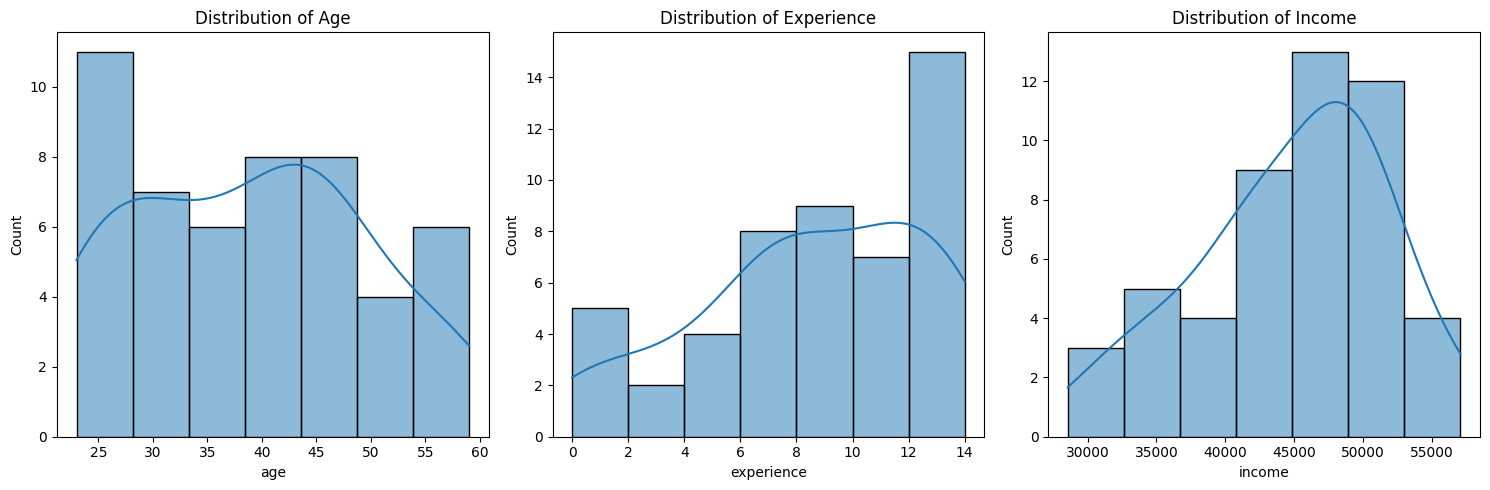

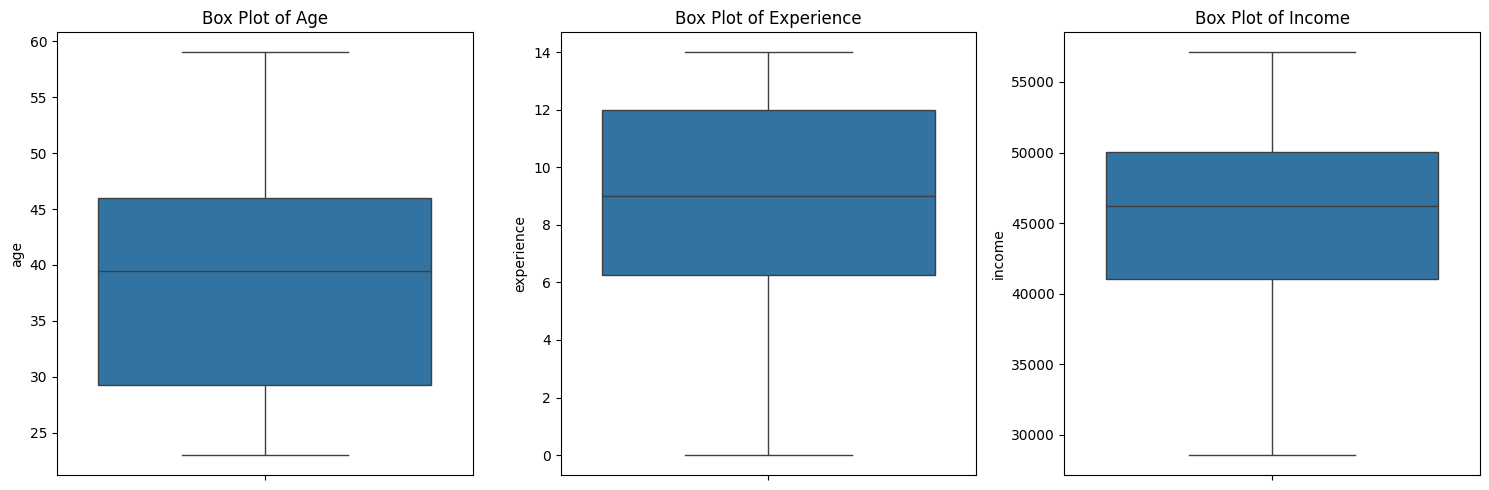

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(employee_df['age'], kde=True)
plt.title('Distribution of Age')

plt.subplot(1, 3, 2)
sns.histplot(employee_df['experience'], kde=True)
plt.title('Distribution of Experience')

plt.subplot(1, 3, 3)
sns.histplot(employee_df['income'], kde=True)
plt.title('Distribution of Income')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=employee_df['age'])
plt.title('Box Plot of Age')

plt.subplot(1, 3, 2)
sns.boxplot(y=employee_df['experience'])
plt.title('Box Plot of Experience')

plt.subplot(1, 3, 3)
sns.boxplot(y=employee_df['income'])
plt.title('Box Plot of Income')

plt.tight_layout()
plt.show()

### 4. Bivariate Analysis: Relationships Between Features
Now, let's explore the relationships between `income` and other numerical features (`age`, `experience`) using scatter plots and calculate the correlation matrix.

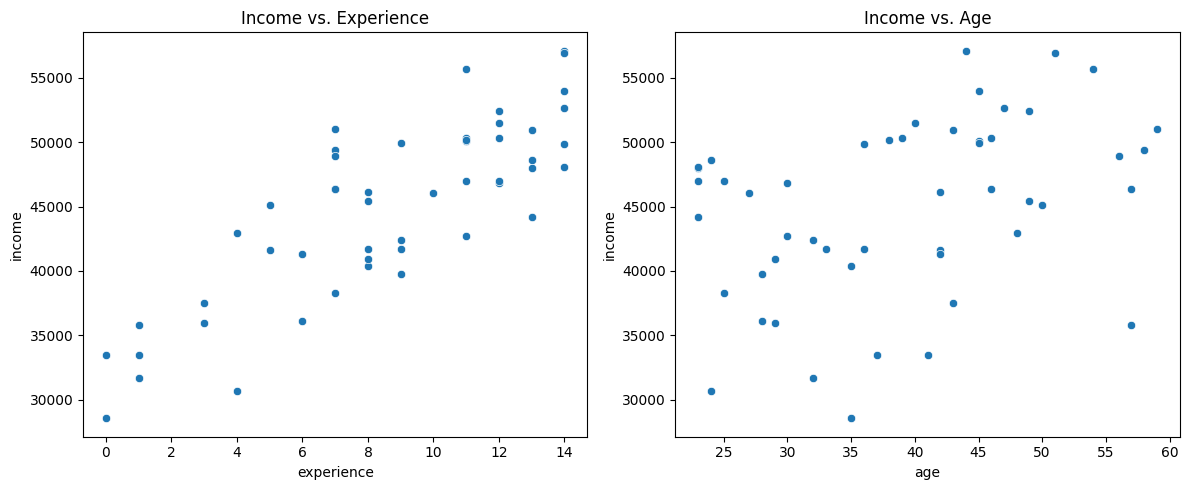

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='experience', y='income', data=employee_df)
plt.title('Income vs. Experience')

plt.subplot(1, 2, 2)
sns.scatterplot(x='age', y='income', data=employee_df)
plt.title('Income vs. Age')

plt.tight_layout()
plt.show()


Correlation Matrix:


,age,experience,income
age,1.00000,-0.139200,0.372720
experience,-0.13920,1.000000,0.827365
income,0.37272,0.827365,1.000000


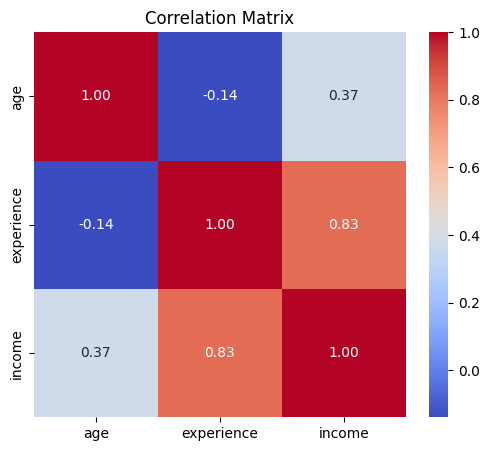

In [ ]:
print('\nCorrelation Matrix:')
correlation_matrix = employee_df.corr()
display(correlation_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### 5. Linear Regression Model
Now, let's build a linear regression model to predict `income` based on `age` and `experience`. We'll split the data into training and testing sets, train the model, and then evaluate its performance.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = employee_df[['age', 'experience']]
y = employee_df['income']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 40 samples
Test set size: 10 samples


#### Train the Linear Regression Model

In [ ]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficients (Age, Experience): {model.coef_}")

Model training complete.
Intercept: 19574.05
Coefficients (Age, Experience): [ 310.82948239 1524.45817564]


#### Evaluate the Model Performance
Let's make predictions on the test set and evaluate the model using metrics like R-squared, Mean Absolute Error (MAE), and Mean Squared Error (MSE).

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 3061367.45
Root Mean Squared Error (RMSE): 1749.68
R-squared (R2): 0.93


#### Visualize Actual vs. Predicted Income
Finally, let's visualize how well our model's predictions align with the actual income values in the test set.

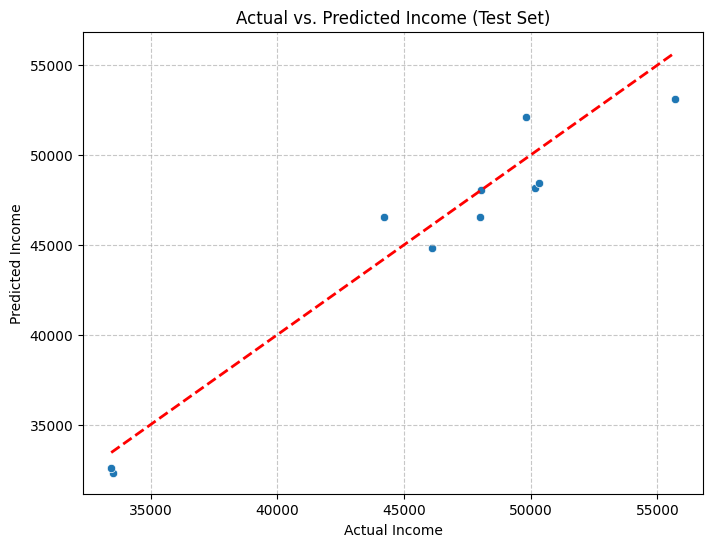

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Line for perfect prediction
plt.xlabel('Actual Income')
plt.ylabel('Predicted Income')
plt.title('Actual vs. Predicted Income (Test Set)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 6. Summary of Regression Metrics
Let's gather all the calculated regression metrics, including Mean Absolute Error (MAE), for a complete overview of the model's performance.

In [ ]:
from sklearn.metrics import mean_absolute_error

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 1581.41
Mean Squared Error (MSE): 3061367.45
Root Mean Squared Error (RMSE): 1749.68
R-squared (R2): 0.93


### 7. Error Analysis: Histogram of Residuals
Let's calculate the residuals (actual income - predicted income) and visualize their distribution using a histogram. This helps in understanding if the errors are normally distributed, which is an assumption in linear regression.

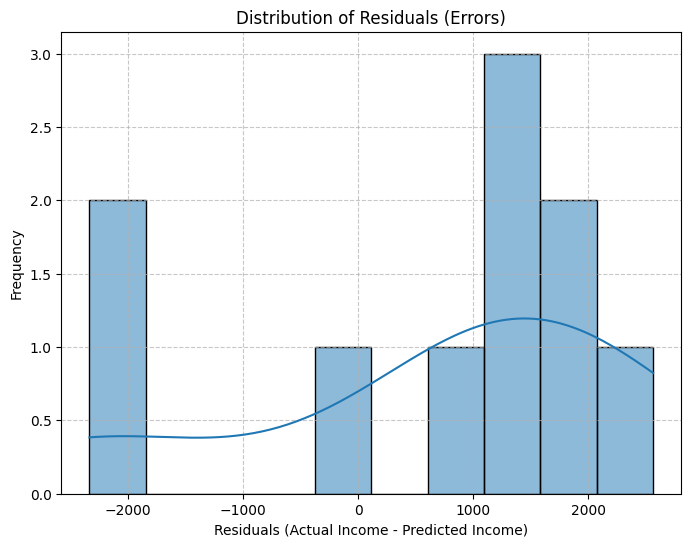

Mean Absolute Percentage Error (MAPE): 3.40%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_percentage_error

# Calculate residuals
residuals = y_test - y_pred

# Plot histogram of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=10)
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Residuals (Actual Income - Predicted Income)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Calculate MAPE
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2%}")